In [1]:
import os
from datetime import datetime
from typing import List
import string
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Union
import app
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from shapely.geometry import Point
from dateutil.rrule import MO

# 0. Import

In [2]:
drainages_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\03_cleaned\drainages"
tides_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\01_raw\tides_CATS2008"
data_dmg_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\03_cleaned\dmg_resampled_masked"
data_img_folder = r"D:\[Code]\HydrofractureShackleton_2023\data-img"
figure_folder = r"D:\PhD\21_Experiments\TidesDamageDriver\figures"

In [3]:
events = app.lakes.plotting.get_geodataframes(drainages_folder)[0]
events.to_crs(
    "EPSG:3031", inplace=True
)
events["start_date"] = pd.to_datetime(events["start_date"])
events["end_date"] = pd.to_datetime(events["end_date"])
events["volume-0"] = np.nan_to_num(x=events["volume-0"].values, nan=0)  # type: ignore
events["volume-1"] = np.nan_to_num(x=events["volume-1"].values, nan=0)  # type: ignore
events["date-0 plotting"] = events.apply(
    lambda row: row["start_date"] + pd.DateOffset(years=2020 - int(row["year"])),
    axis=1
)
events["date-1 plotting"] = events.apply(
    lambda row: row["end_date"] + pd.DateOffset(years=2020 - int(row["year"])),
    axis=1
)
events["year"] = events["year"].astype(int)

In [4]:
events

,label,index,year,lon,lat,start_date,end_date,mean-0,median-0,area-0,...,dmg,dmg_cat,act,act_cat,lai,fuerst,fuerst+lai,geometry,date-0 plotting,date-1 plotting
0,A,29,2019,95.688019,-66.671201,2019-12-24,2019-12-31,1.130955,1.104492,66600.0,...,0.235667,high,0.269375,medium,NaN,NaN,NaN,"POLYGON ((2556180 -254280, 2556210 -254280, 25...",2020-12-24,2020-12-31
1,B,28,2019,95.737264,-66.660983,2019-12-22,2019-12-31,1.283588,1.089844,55800.0,...,0.333090,high,0.458099,medium,1.0,0.0,1.0,"POLYGON ((2557200 -256740, 2557290 -256740, 25...",2020-12-22,2020-12-31
2,C,39,2019,95.759349,-66.646830,2020-01-07,2020-01-13,0.569657,NaN,NaN,...,0.333090,high,0.458099,medium,1.0,0.0,1.0,"POLYGON ((2558709.399 -258069.242, 2558709.351...",2021-01-07,2021-01-13
3,D,8,2016,96.040652,-66.571884,2017-01-27,2017-02-03,1.441006,1.357422,90900.0,...,0.356259,high,0.574090,medium,1.0,0.0,1.0,"POLYGON ((2565840 -271140, 2565870 -271140, 25...",2021-01-27,2021-02-03
4,E,32,2019,97.782530,-66.594982,2020-01-30,2020-02-03,2.299795,2.486328,154800.0,...,0.139619,medium,0.533078,medium,1.0,0.0,1.0,"POLYGON ((2553540 -348870, 2553570 -348870, 25...",2021-01-30,2021-02-03
5,F,40,2019,98.104002,-66.492315,2020-01-30,2020-02-03,1.125474,NaN,NaN,...,0.169961,high,0.513592,medium,1.0,1.0,2.0,"POLYGON ((2563316.902 -364995.272, 2563316.854...",2021-01-30,2021-02-03
6,G,41,2019,98.493578,-65.782618,2020-01-04,2020-01-11,0.583205,NaN,NaN,...,0.430535,high,0.801361,high,1.0,0.0,1.0,"POLYGON ((2640312.345 -394293.286, 2640312.297...",2021-01-04,2021-01-11
7,H,17,2018,98.847890,-66.359584,2019-01-31,2019-02-08,0.914807,0.891113,99900.0,...,0.284860,high,0.313371,medium,0.0,0.0,0.0,"POLYGON ((2573160 -400260, 2573250 -400260, 25...",2021-01-31,2021-02-08
8,I,26,2019,98.870325,-66.357777,2020-01-20,2020-01-27,0.860971,0.859863,93600.0,...,0.256579,high,0.386947,medium,0.0,0.0,0.0,"POLYGON ((2573340 -401340, 2573400 -401340, 25...",2021-01-20,2021-01-27
9,J,23,2019,99.719303,-66.264245,2020-01-04,2020-01-11,0.992884,1.030273,59400.0,...,0.135486,medium,0.681241,high,0.0,0.0,0.0,"POLYGON ((2577360 -441270, 2577390 -441270, 25...",2021-01-04,2021-01-11


In [5]:
tides = app.tides.load_tide_files(
    [
        os.path.join(tides_folder, f)
        for f in os.listdir(tides_folder)
        if "tides" in f.lower() and "2015" in f
    ]
)

In [6]:
tides["plotting_date"] = tides["date"]
for i_year, year in enumerate(tides.year.unique()):
    tides.loc[tides.year == year, "plotting_date"] = tides["date"] + pd.DateOffset(years=2020 - year)
tides["plotting_month"] = tides["plotting_date"].dt.month

for i_year, year in enumerate(tides.year.unique()):
    #drains_summer = events.query("year== @year")
    tides_summer = tides.query("year == @year")

    date_list = pd.Series(tides_summer.date).dt.date.tolist()

In [7]:
def set_offset(label: str) -> float:
        if label in ["G"]:
            return -3
        
        if label in ["E", "D", "O", "X"]:
            return -2
        elif label in ["A", "S", "Q", "N"]:
            return -1
        elif label in ["L", "W"]:
            return 1.5
        
        elif label in ["F", "P", "W"]:
            return 1
        elif label in ["I", "K"]:
            return 2.5
        elif label in ["B"]:
            return 3.5
        else:
            return 0

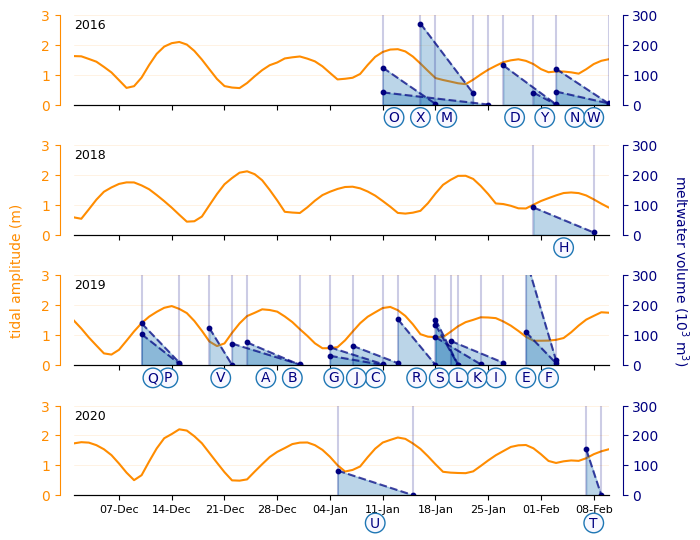

In [8]:
ymin = 0
ymax = 3
ymax_volume = 300
y_label = -0.2

color_tide = "darkorange"
color_water = "navy"

years = [2016, 2018, 2019, 2020]
months = [11, 12, 1, 2]
fig, axes = plt.subplots(len(years), 1, figsize=(18 / 2.54, 14 / 2.54), sharex=True)
for i_year, year in enumerate(years):
    if i_year == 3:
        y_offset = -0.5
    else:
        y_offset = 0.0
    events_year = events.query("year == @year").copy()
    tides_year = tides.query("year == @year").copy()
    tides_year = tides_year.query("plotting_month in @months").copy()
    ax = axes.ravel()[i_year]
    ax_ = ax.twinx()

    ax.plot(tides_year.plotting_date, tides_year.tide, color = color_tide, zorder = 1)
    ax.text(
        x=0, y=0.96, s=year, transform=ax.transAxes, ha="left", va="top", fontsize=9
    )

    volume0 = events_year["volume-0"] / 1e3
    volume1 = events_year["volume-1"] / 1e3

    date0 = events_year["date-0 plotting"]
    date1 = events_year["date-1 plotting"]

    ax_.scatter(date0, volume0, color=color_water, s=10, zorder=2)
    ax_.scatter(date1, volume1, color=color_water, s=10, zorder=2)
    for _, row in events_year.iterrows():
        ax_.fill_between(
            [row["date-0 plotting"], row["date-1 plotting"]],
            [0, 0],
            [row["volume-0"] / 1e3, row["volume-1"] / 1e3],
            color="tab:blue",
            alpha=0.3,
            zorder=1,
        )

    
    
    events_year["offset"] = pd.to_timedelta(events_year.apply(
        lambda row: set_offset(row["label"]), axis=1
    ), unit="D")
    events_year["midpoint_timestamp"] = events_year["start_date"] + (events_year["end_date"] - events_year["start_date"]) / 2 + events_year["offset"]

    for row in events_year.iterrows():
        ax.text(
            row[1]["midpoint_timestamp"] + pd.DateOffset(years=2020 - year),
            y_label + y_offset,
            row[1]["label"],
            ha="center",
            va="top",
            color="navy",
            bbox=dict(
                edgecolor="tab:blue", facecolor="ghostwhite", boxstyle="circle,pad=0.2"
            ),
        )
        ax_.plot(
            [row[1]["date-0 plotting"], 
            row[1]["date-1 plotting"]],
            [row[1]["volume-0"] / 1e3, row[1]["volume-1"] / 1e3],
            color = color_water,
            ls = "--", alpha = 0.7, zorder = 10)

    ax.set_ylim(ymin, ymax)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))
    ax.tick_params(axis="x", labelsize=8)
    ax.spines.left.set_position(("outward", 10))
    ax.spines.left.set_color(color_tide)
    ax.tick_params(axis="y", colors=color_tide)
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.grid(alpha = 0.2, color = color_tide, zorder = 0, axis = "y", lw = 0.4)

    
    ax_.set_ylim(0, ymax_volume)
    ax_.yaxis.set_major_locator(ticker.MultipleLocator(100))
    ax_.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))
    ax_.spines.right.set_position(("outward", 10))
    ax_.spines.right.set_color(color_water)
    ax_.tick_params(axis="y", colors=color_water)
    ax_.spines.left.set_visible(False)
    ax_.spines.top.set_visible(False)
    for d in pd.concat([events_year["start_date"], events_year["end_date"]]).unique():
        ax_.axvline(
            pd.Timestamp(d) + pd.DateOffset(years=2020 - int(year)), ls="-", color=color_water, alpha=0.2, lw = 1.5, zorder = 2
        )
        


ax = axes.ravel()[0]
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax.set_xlim([datetime(2020, 12, 1), datetime(2021, 2, 10)])

fig.text(0.02, 0.5, r"tidal amplitude (m)", ha="left", va="center", color=color_tide, rotation=90)
fig.text(
    0.98,
    0.5,
    r"meltwater volume ($10^3$ m$^3$)",
    ha="right",
    va="center",
    color=color_water,
    rotation=-90,
)

plt.tight_layout()
plt.subplots_adjust(left=0.11, right=0.865)
fig.savefig(os.path.join(figure_folder, "figure_03.pdf"), dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(os.path.join(figure_folder, "figure_03.png"), dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(os.path.join(figure_folder, "figure_03.svg"), dpi=300, bbox_inches='tight', transparent=True)
plt.show()